In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

In [2]:
wine = load_wine()

print("Wine dataset loaded successfully!")

Wine dataset loaded successfully!


In [3]:
df = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

df["target"] = wine.target

print("Dataset Shape:", df.shape)

display(df.head())

Dataset Shape: (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [4]:
print("Dataset Information:\n")

df.info()

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null

In [5]:
display(df.describe())

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [6]:
print("Missing Values:\n")

display(df.isnull().sum())

Missing Values:



alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

In [7]:
X = df.drop("target", axis=1)
y = df["target"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFeatures:")
display(X.head())

print("\nTarget:")
display(y.head())

Features Shape: (178, 13)
Target Shape: (178,)

Features:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0



Target:


0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Features Shape: (142, 13)
Testing Features Shape: (36, 13)
Training Target Shape: (142,)
Testing Target Shape: (36,)


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data scaled successfully!")
print("Testing data scaled successfully!")

print("\nScaled Training Shape:", X_train_scaled.shape)
print("Scaled Testing Shape:", X_test_scaled.shape)

Training data scaled successfully!
Testing data scaled successfully!

Scaled Training Shape: (142, 13)
Scaled Testing Shape: (36, 13)


In [10]:
qda = QuadraticDiscriminantAnalysis()

print("QDA Model Created Successfully!")
print(qda)

QDA Model Created Successfully!
QuadraticDiscriminantAnalysis()


In [11]:
qda.fit(X_train_scaled, y_train)

print("QDA model trained successfully!")

QDA model trained successfully!


In [12]:
y_pred = qda.predict(X_test_scaled)

print("Predictions generated successfully!")

print("\nPredicted Classes:")
print(y_pred)

Predictions generated successfully!

Predicted Classes:
[0 2 0 1 1 0 0 1 1 2 1 2 0 2 0 1 1 0 1 0 1 1 0 0 1 1 0 2 1 2 0 2 1 2 2 2]


In [13]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("QDA Accuracy:", accuracy)
print("QDA Accuracy (%):", accuracy * 100)

QDA Accuracy: 1.0
QDA Accuracy (%): 100.0


In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
display(pd.DataFrame(
    cm,
    index=["Actual Class 0", "Actual Class 1", "Actual Class 2"],
    columns=["Predicted Class 0", "Predicted Class 1", "Predicted Class 2"]
))

Confusion Matrix:


,Predicted Class 0,Predicted Class 1,Predicted Class 2
Actual Class 0,12,0,0
Actual Class 1,0,14,0
Actual Class 2,0,0,10


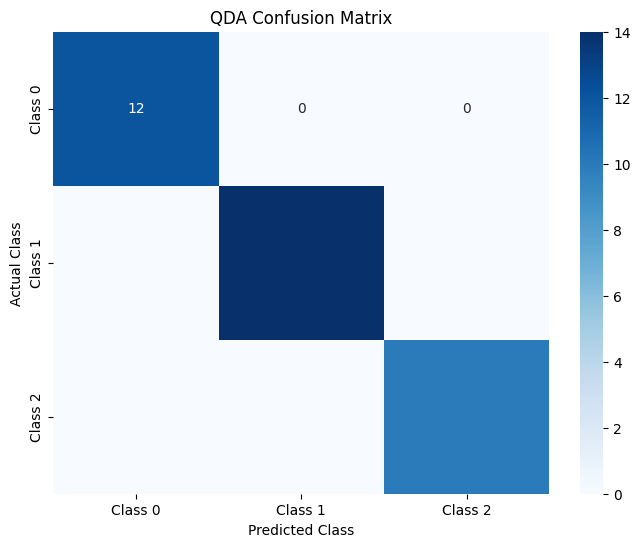

In [15]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Class 0", "Class 1", "Class 2"],
    yticklabels=["Class 0", "Class 1", "Class 2"]
)

plt.title("QDA Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [16]:
from sklearn.metrics import classification_report

print("QDA Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

QDA Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [17]:
y_proba = qda.predict_proba(X_test_scaled)

probability_df = pd.DataFrame(
    y_proba,
    columns=[
        "Class 0 Probability",
        "Class 1 Probability",
        "Class 2 Probability"
    ]
)

display(probability_df.head(10))

,Class 0 Probability,Class 1 Probability,Class 2 Probability
0,1.000000e+00,5.263223e-16,7.325627e-135
1,1.181321e-72,1.061149e-08,1.000000e+00
2,9.999999e-01,1.380594e-07,1.042967e-90
3,3.777541e-19,1.000000e+00,7.645106e-229
4,7.197742e-11,1.000000e+00,3.189310e-38
5,1.000000e+00,4.451548e-14,1.050913e-114
6,1.000000e+00,1.063138e-14,4.897280e-80
7,5.483308e-06,9.999945e-01,3.910844e-125
8,2.667010e-10,1.000000e+00,7.856394e-32
9,5.232452e-89,8.694347e-32,1.000000e+00


In [18]:
comparison_df = pd.DataFrame({
    "Actual Class": y_test.values,
    "Predicted Class": y_pred
})

display(comparison_df.head(20))

,Actual Class,Predicted Class
0,0,0
1,2,2
2,0,0
3,1,1
4,1,1
5,0,0
6,0,0
7,1,1
8,1,1
9,2,2


In [19]:
print("========== QDA MODEL SUMMARY ==========")

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))
print("Number of Features:", X.shape[1])
print("Number of Classes :", len(np.unique(y)))

print("\nAccuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

========== QDA MODEL SUMMARY ==========
Training Samples : 142
Testing Samples  : 36
Number of Features: 13
Number of Classes : 3

Accuracy: 1.0
Accuracy (%): 100.0


In [20]:
print("========== FINAL CONCLUSION ==========")

print(
    f"QDA achieved an accuracy of {accuracy * 100:.2f}% "
    "on the test dataset."
)

print(
    "Quadratic Discriminant Analysis was successfully "
    "trained and evaluated on the Wine dataset."
)

========== FINAL CONCLUSION ==========
QDA achieved an accuracy of 100.00% on the test dataset.
Quadratic Discriminant Analysis was successfully trained and evaluated on the Wine dataset.
